# Legal Clause Classification with CUAD

This notebook downloads the original CUAD dataset from Hugging Face, prepares a flattened clause-level table, and walks through exploratory data analysis on the extracted data.


In [3]:
# Section 0 — Install & imports
# ── Run this cell first, every session ───────────────────────────────────────
# Clones the repo so all .py modules are available without manual file upload.

import sys, os

REPO_URL    = "https://github.com/pranaysamineni00/BT5153.git"
REPO_BRANCH = "main"
REPO_DIR    = "/content/BT5153"

if not os.path.exists(REPO_DIR):
    ret = os.system(f"git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}")
    if ret != 0:
        raise RuntimeError(f"git clone failed (exit {ret}). Check REPO_URL and REPO_BRANCH.")
else:
    os.system(f"git -C {REPO_DIR} pull --ff-only")   # keep in sync on re-runs

# Verify expected modules are present
expected = ["data_loading.py", "preprocessing.py", "training.py", "evaluation.py"]
missing  = [f for f in expected if not os.path.exists(os.path.join(REPO_DIR, f))]
if missing:
    print("Files in REPO_DIR:", os.listdir(REPO_DIR))
    raise FileNotFoundError(f"Missing modules after clone: {missing}")

sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")
os.makedirs("figures", exist_ok=True)

%pip install -q pandas pyarrow huggingface_hub matplotlib seaborn torch transformers \
    scikit-learn accelerate datasets

import importlib
import data_loading, preprocessing, training, evaluation

for mod in [data_loading, preprocessing, training, evaluation]:
    importlib.reload(mod)

from data_loading import load_cuad, load_ledgar
from preprocessing import (
    filter_clauses, plot_clause_frequency, build_clause_mappings,
    build_contract_records, split_contract_records, build_chunk_examples,
    MultiLabelChunkDataset, prepare_chunked_splits, sample_contracts, AutoTokenizer,
    aggregate_contract_predictions,
)
from training import (
    train_tfidf_lr, train_bert_ledgar_cuad, train_bert_cuad,
    train_legal_bert_cuad, train_longformer_cuad, train_legalbert_longformer_cuad,
    collect_logits_and_labels, choose_device,
)
from evaluation import (
    tune_per_clause_thresholds, compute_per_clause_metrics,
    compute_aggregate_metrics, plot_confusion_matrix, plot_model_comparison,
)
from IPython.display import display
import numpy as np
import pandas as pd


Working directory: /content/BT5153


In [4]:
from pathlib import Path

from huggingface_hub import hf_hub_download

raw_json_path = Path("data/cuad/CUAD_v1/CUAD_v1.json")
raw_json_path.parent.mkdir(parents=True, exist_ok=True)

if not raw_json_path.exists():
    downloaded_path = hf_hub_download(
        repo_id="theatticusproject/cuad",
        repo_type="dataset",
        filename="CUAD_v1/CUAD_v1.json",
        local_dir="data/cuad",
    )
    raw_json_path = Path(downloaded_path)

raw_json_path


PosixPath('data/cuad/CUAD_v1/CUAD_v1.json')

In [5]:
import json

with raw_json_path.open() as f:
    cuad = json.load(f)

documents = cuad["data"]
version = cuad.get("version")

print(f"CUAD version: {version}")
print(f"Number of contracts: {len(documents)}")
print(f"Paragraph keys: {list(documents[0]['paragraphs'][0].keys())}")
print(f"Questions per first contract: {len(documents[0]['paragraphs'][0]['qas'])}")


CUAD version: aok_v1.0
Number of contracts: 510
Paragraph keys: ['qas', 'context']
Questions per first contract: 41


In [6]:
import pandas as pd

rows = []

for doc in documents:
    for paragraph in doc["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            answers = qa.get("answers", [])
            rows.append(
                {
                    "contract_title": doc["title"],
                    "clause_type": qa["id"].split("__", 1)[-1],
                    "question": qa["question"],
                    "contract_text": context,
                    "is_impossible": qa["is_impossible"],
                    "has_answer": bool(answers),
                    "answer_count": len(answers),
                    "answer_texts": [answer["text"] for answer in answers],
                    "answer_starts": [answer["answer_start"] for answer in answers],
                }
            )

cuad_df = pd.DataFrame(rows)
flat_path = Path("data/cuad/cuad_qa_rows.parquet")
cuad_df.to_parquet(flat_path, index=False)

print(cuad_df.shape)
flat_path


(20910, 9)


PosixPath('data/cuad/cuad_qa_rows.parquet')

In [7]:

cuad_df

,contract_title,clause_type,question,contract_text,is_impossible,has_answer,answer_count,answer_texts,answer_starts
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[DISTRIBUTOR AGREEMENT],[44]
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,5,"[Distributor, Electric City Corp., Electric Ci...","[244, 148, 49574, 197, 212]"
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,"[7th day of September, 1999.]",[263]
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,2,[The term of this Agreement shall be ten (10...,"[5268, 31058]"
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[The term of this Agreement shall be ten (10...,[5268]
...,...,...,...,...,...,...,...,...,...
20905,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Liquidated Damages,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20906,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Warranty Duration,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20907,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Insurance,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,False,True,3,"[Company agrees, at its own expense, to obtain...","[20750, 21123, 21313]"
20908,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Covenant Not To Sue,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]


In [8]:
cuad_df['question'][100]

'Highlight the parts (if any) of this contract related to "Anti-Assignment" that should be reviewed by a lawyer. Details: Is consent or notice required of a party if the contract is assigned to a third party?'

## EDA

The cells below summarize class balance, contract length, clause coverage, and answer span behavior in the extracted CUAD table.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

cuad_df["contract_char_count"] = cuad_df["contract_text"].str.len()
cuad_df["contract_word_count"] = cuad_df["contract_text"].str.split().str.len()
cuad_df["question_word_count"] = cuad_df["question"].str.split().str.len()
cuad_df["answer_char_total"] = cuad_df["answer_texts"].apply(lambda answers: sum(len(answer) for answer in answers))

contract_df = cuad_df[["contract_title", "contract_char_count", "contract_word_count"]].drop_duplicates()

clause_summary = (
    cuad_df.groupby("clause_type")
    .agg(
        total_rows=("clause_type", "size"),
        positive_rows=("has_answer", "sum"),
        positive_rate=("has_answer", "mean"),
        avg_answer_count=("answer_count", "mean"),
    )
    .sort_values(["positive_rows", "positive_rate"], ascending=[False, False])
)

contract_positive_counts = (
    cuad_df.groupby("contract_title")["has_answer"]
    .sum()
    .reset_index(name="positive_clause_count")
    .merge(contract_df, on="contract_title", how="left")
)

answer_spans_df = cuad_df.explode(["answer_texts", "answer_starts"], ignore_index=True)
answer_spans_df = answer_spans_df[answer_spans_df["answer_texts"].notna()].copy()
answer_spans_df["answer_span_word_count"] = answer_spans_df["answer_texts"].str.split().str.len()
answer_spans_df["answer_span_char_count"] = answer_spans_df["answer_texts"].str.len()


In [10]:
print(f"Clause-level rows: {len(cuad_df):,}")
print(f"Contracts: {contract_df['contract_title'].nunique():,}")
print(f"Clause types: {cuad_df['clause_type'].nunique():,}")
print(f"Positive rate: {cuad_df['has_answer'].mean():.2%}")
print(f"Average answers per row: {cuad_df['answer_count'].mean():.2f}")
print(f"Average words per contract: {contract_df['contract_word_count'].mean():,.0f}")

display(cuad_df[["has_answer", "answer_count", "contract_word_count", "question_word_count", "answer_char_total"]].describe())
display(clause_summary.head(10))


Clause-level rows: 20,910
Contracts: 510
Clause types: 41
Positive rate: 32.05%
Average answers per row: 0.66
Average words per contract: 7,861


,answer_count,contract_word_count,question_word_count,answer_char_total
count,20910.000000,20910.000000,20910.000000,20910.000000
mean,0.661071,7861.188235,42.024390,173.213152
std,1.549586,8359.285183,11.139053,557.608343
min,0.000000,109.000000,25.000000,0.000000
25%,0.000000,2452.000000,36.000000,0.000000
50%,0.000000,5006.000000,40.000000,0.000000
75%,1.000000,10211.000000,48.000000,69.000000
max,55.000000,47733.000000,80.000000,15262.000000


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


/tmp/ipykernel_12151/603424307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_balance.index, y=overall_balance.values, ax=axes[0], palette="Set2")


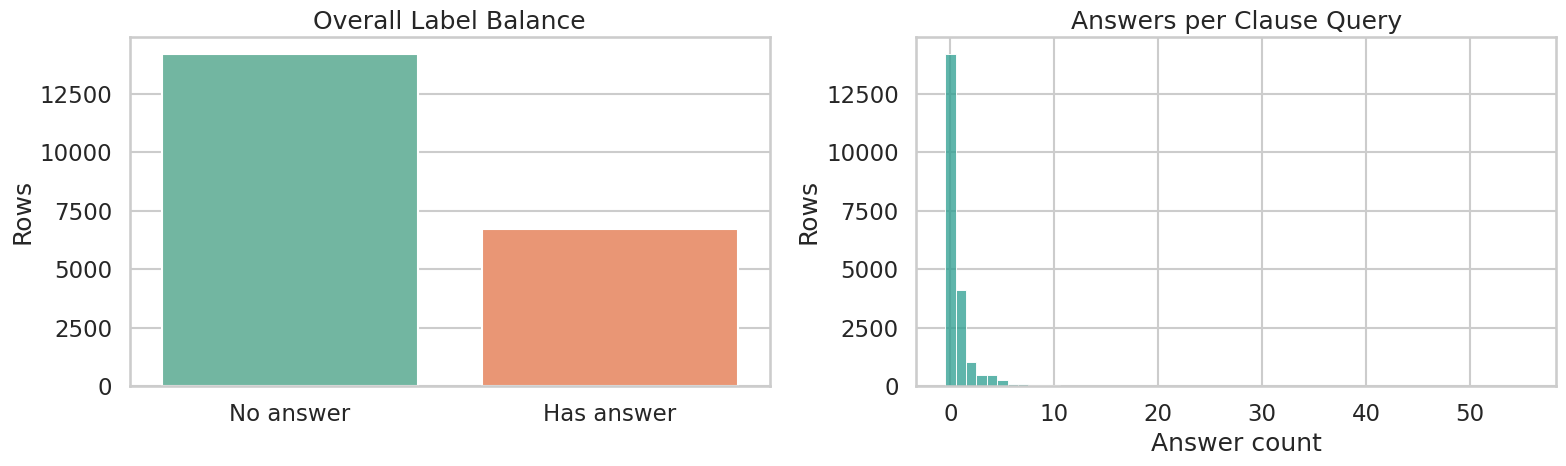

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

overall_balance = cuad_df["has_answer"].value_counts().rename(index={True: "Has answer", False: "No answer"})
sns.barplot(x=overall_balance.index, y=overall_balance.values, ax=axes[0], palette="Set2")
axes[0].set_title("Overall Label Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")

sns.histplot(cuad_df["answer_count"], bins=15, discrete=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Answers per Clause Query")
axes[1].set_xlabel("Answer count")
axes[1].set_ylabel("Rows")

plt.tight_layout()


/tmp/ipykernel_12151/2476789065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_positive_counts, x="positive_rows", y=top_positive_counts.index, ax=axes[0], palette="crest")
/tmp/ipykernel_12151/2476789065.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_positive_rates, x="positive_rate", y=top_positive_rates.index, ax=axes[1], palette="flare")


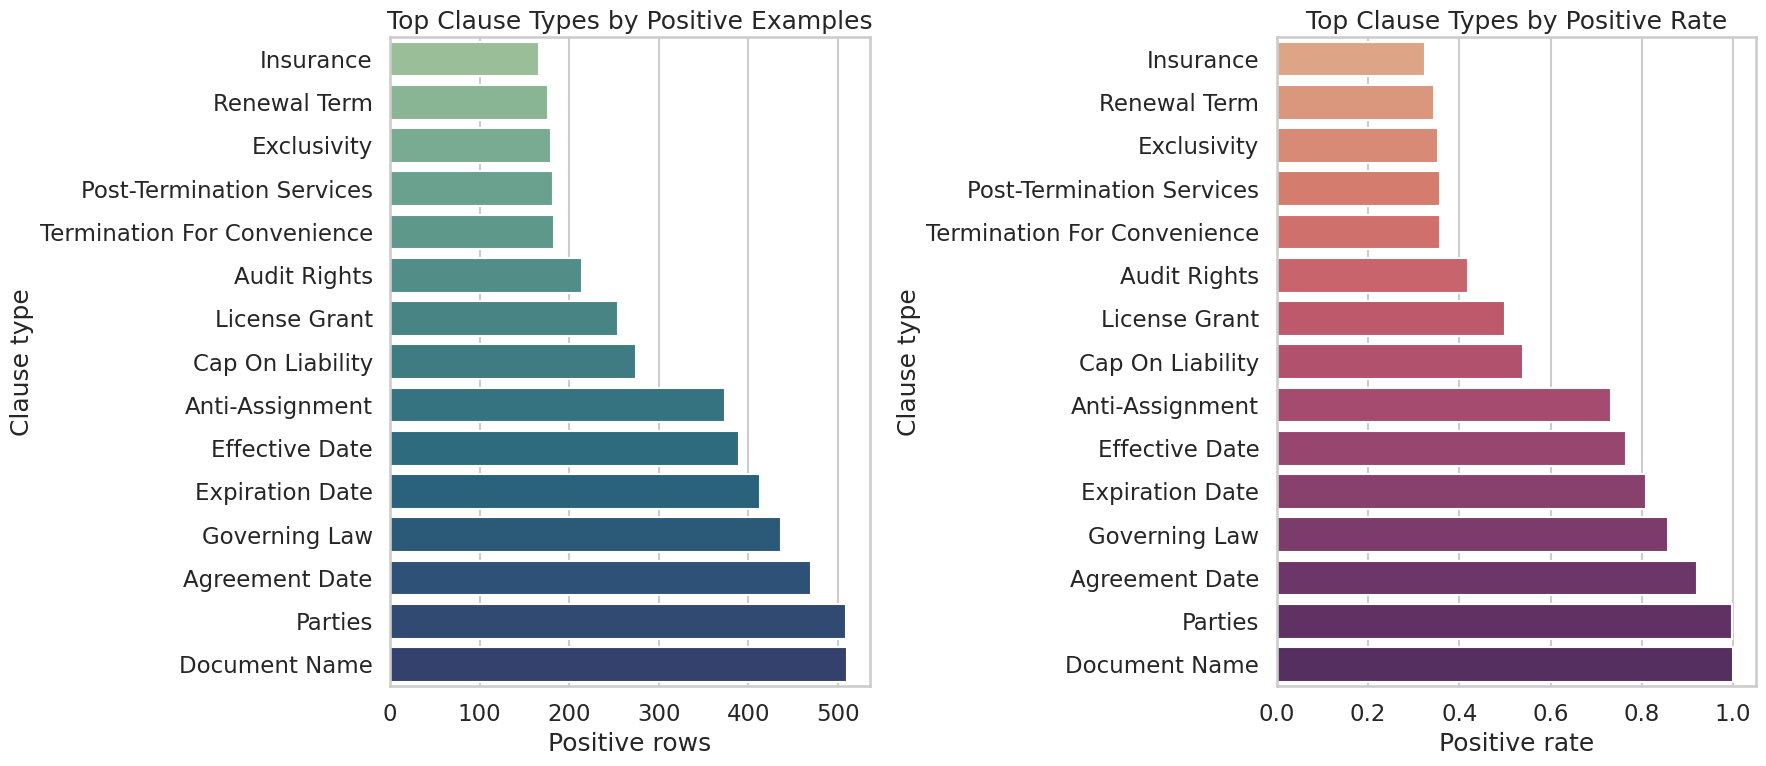

In [12]:
top_positive_counts = clause_summary.head(15).sort_values("positive_rows")
top_positive_rates = clause_summary.sort_values("positive_rate", ascending=False).head(15).sort_values("positive_rate")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=top_positive_counts, x="positive_rows", y=top_positive_counts.index, ax=axes[0], palette="crest")
axes[0].set_title("Top Clause Types by Positive Examples")
axes[0].set_xlabel("Positive rows")
axes[0].set_ylabel("Clause type")

sns.barplot(data=top_positive_rates, x="positive_rate", y=top_positive_rates.index, ax=axes[1], palette="flare")
axes[1].set_title("Top Clause Types by Positive Rate")
axes[1].set_xlabel("Positive rate")
axes[1].set_ylabel("Clause type")

plt.tight_layout()


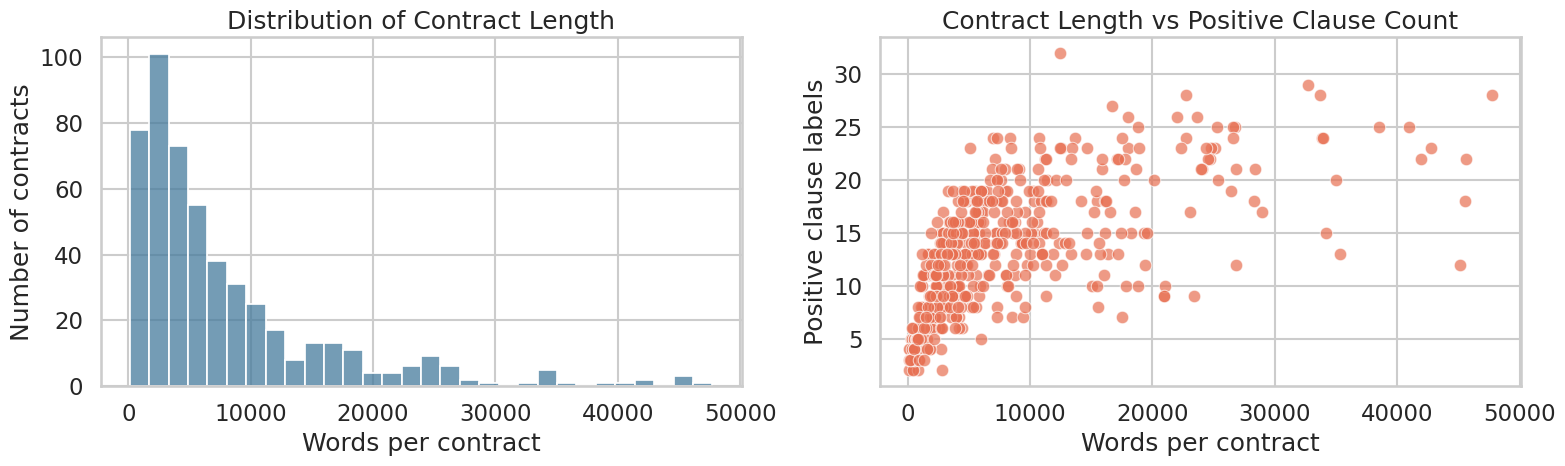

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(contract_df["contract_word_count"], bins=30, ax=axes[0], color="#457b9d")
axes[0].set_title("Distribution of Contract Length")
axes[0].set_xlabel("Words per contract")
axes[0].set_ylabel("Number of contracts")

sns.scatterplot(
    data=contract_positive_counts,
    x="contract_word_count",
    y="positive_clause_count",
    ax=axes[1],
    alpha=0.7,
    color="#e76f51",
)
axes[1].set_title("Contract Length vs Positive Clause Count")
axes[1].set_xlabel("Words per contract")
axes[1].set_ylabel("Positive clause labels")

plt.tight_layout()


/tmp/ipykernel_12151/3233914451.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_answers_per_clause, x="avg_answer_count", y=avg_answers_per_clause.index, ax=axes[1], palette="mako")


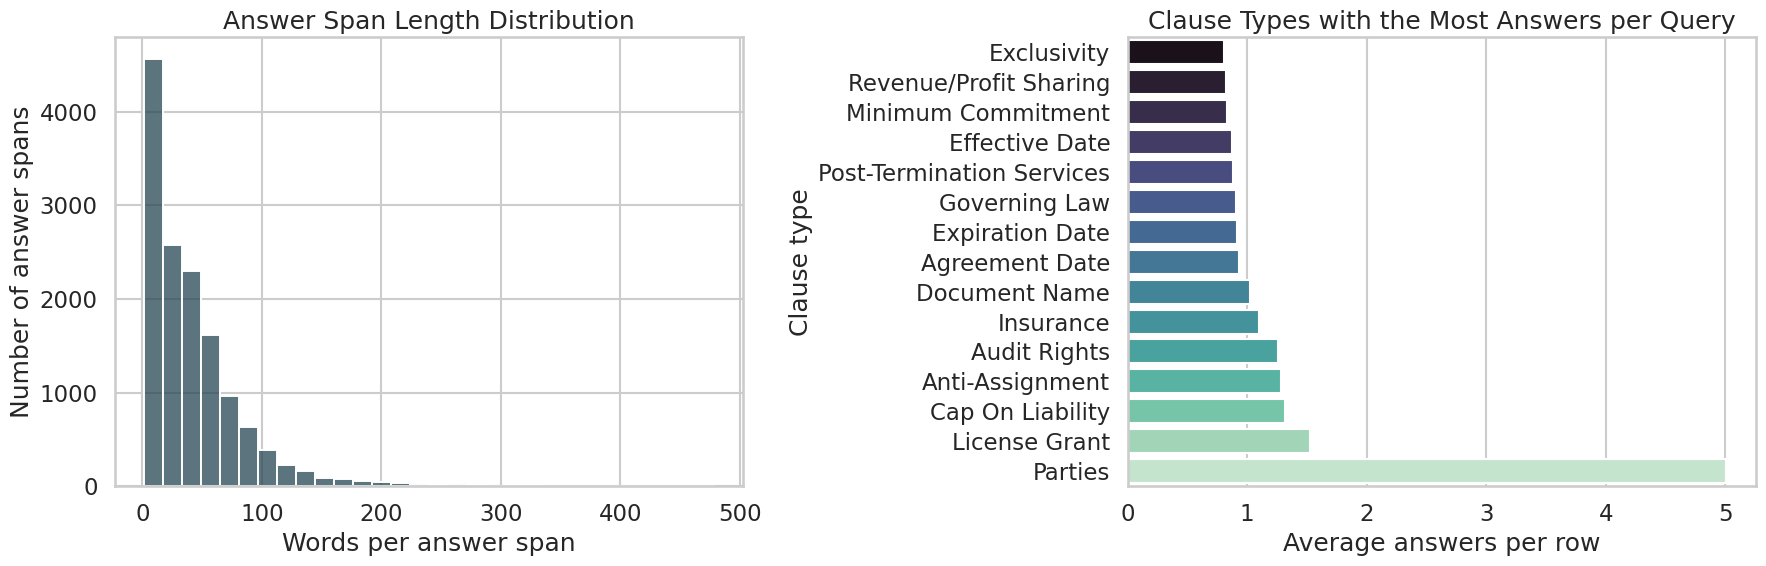

In [14]:
avg_answers_per_clause = clause_summary.sort_values("avg_answer_count", ascending=False).head(15).sort_values("avg_answer_count")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(answer_spans_df["answer_span_word_count"], bins=30, ax=axes[0], color="#264653")
axes[0].set_title("Answer Span Length Distribution")
axes[0].set_xlabel("Words per answer span")
axes[0].set_ylabel("Number of answer spans")

sns.barplot(data=avg_answers_per_clause, x="avg_answer_count", y=avg_answers_per_clause.index, ax=axes[1], palette="mako")
axes[1].set_title("Clause Types with the Most Answers per Query")
axes[1].set_xlabel("Average answers per row")
axes[1].set_ylabel("Clause type")

plt.tight_layout()


In [15]:
clause_summary.sort_values(["positive_rate", "positive_rows"], ascending=[False, False])


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


## Section 1 — Load Datasets

In [16]:
# Section 1 — Load datasets
cuad_df = load_cuad("data/cuad")
ledgar  = load_ledgar("data/ledgar")


CUAD loaded: 510 contracts, 41 clause types, 20,910 rows, positive rate 32.05%


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


LEDGAR loaded: 60,000 train examples, 100 categories


## Section 2 — EDA, Clause Filtering & Chunking

/content/BT5153/preprocessing.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="positive_rate", y="clause_type", ax=ax, palette="crest")


,clause_type,positive_rate,positive_count,total
0,Document Name,1.000000,510,510
1,Parties,0.998039,509,510
2,Agreement Date,0.921569,470,510
3,Governing Law,0.856863,437,510
4,Expiration Date,0.809804,413,510
5,Effective Date,0.764706,390,510
6,Anti-Assignment,0.733333,374,510
7,Cap On Liability,0.539216,275,510
8,License Grant,0.500000,255,510
9,Audit Rights,0.419608,214,510


Excluded 3 clause types (below min_positives=20):
  Source Code Escrow: 13 positives
  Price Restrictions: 15 positives
  Unlimited/All-You-Can-Eat-License: 17 positives

Retained clause types: 38
Excluded: ['Price Restrictions', 'Source Code Escrow', 'Unlimited/All-You-Can-Eat-License']
sample_contracts: using 102/510 contracts (20%)
Train chunks: 2,309 | Val: 230 | Test: 356
sample_contracts: using 102/510 contracts (20%)
Longformer train chunks: 311 | Val: 32 | Test: 49


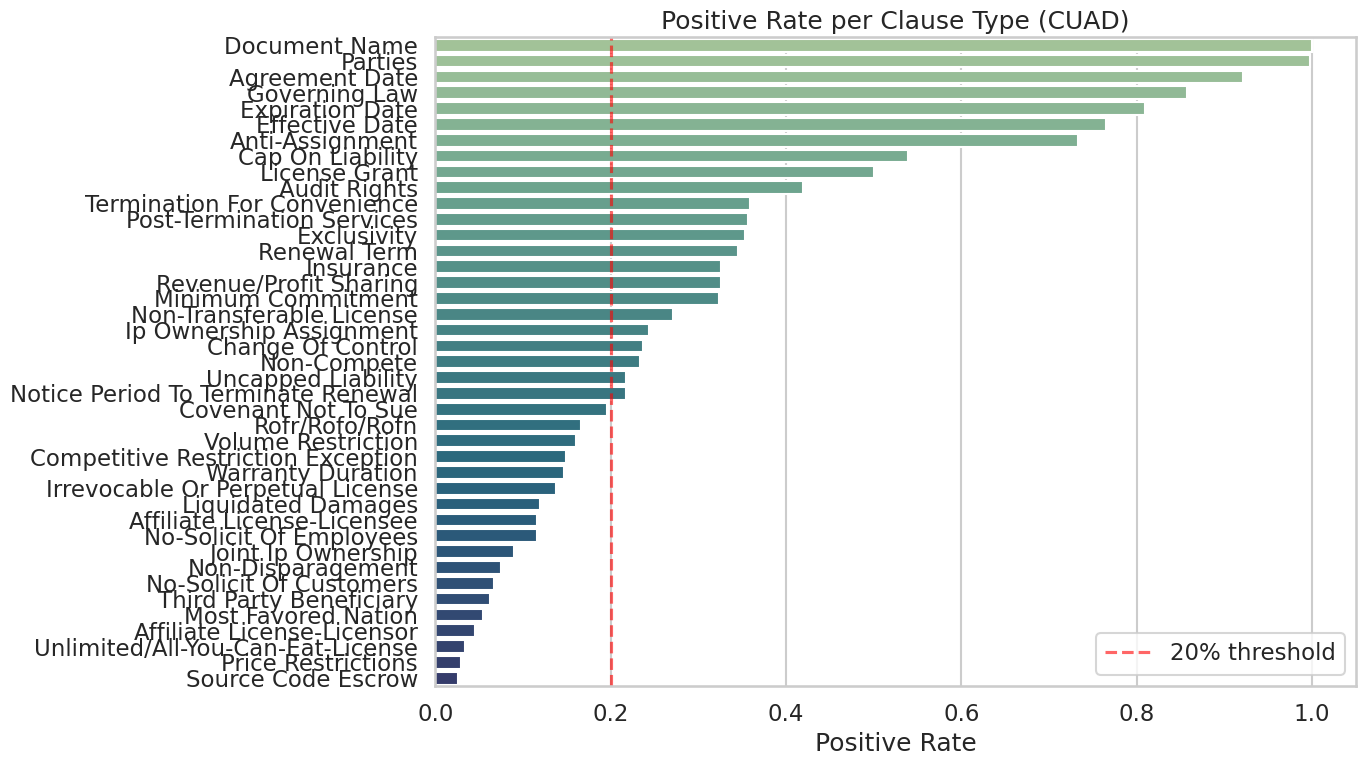

In [17]:
# Section 2 — EDA + clause filtering + chunking
# ── Runtime configuration ────────────────────────────────────────────────────
# DEV_MODE=True  → 40% of contracts, 1 epoch, capped LEDGAR batches (~10-20 min per model)
# DEV_MODE=False → full dataset, 3 epochs (original settings, ~5 hours total)
# Flip to False for the final submission run.
DEV_MODE = True

SAMPLE_FRAC        = 0.40 if DEV_MODE else 1.0
TRAIN_EPOCHS       = 1    if DEV_MODE else 3
LEDGAR_MAX_BATCHES = 100  if DEV_MODE else None  # caps LEDGAR warm-up to ~1,600 examples

# 2a. Bar chart — positive rate per clause type
import os; os.makedirs("figures", exist_ok=True)
clause_summary = plot_clause_frequency(cuad_df, save_path="figures/clause_frequency.png")
display(clause_summary.head(20))

# 2b. Filter clauses below threshold
MIN_POSITIVES = 20
filtered_df, excluded_clauses = filter_clauses(cuad_df, min_positives=MIN_POSITIVES)
print(f"\nRetained clause types: {filtered_df['clause_type'].nunique()}")
print(f"Excluded: {list(excluded_clauses.keys())}")

# 2c. Prepare BERT-family chunks (512 tokens, stride 128)
BERT_SPLITS = prepare_chunked_splits(
    filtered_df, model_name="bert-base-uncased", max_length=512, stride=128, seed=42,
    sample_frac=SAMPLE_FRAC,
)
print(f"Train chunks: {len(BERT_SPLITS['train_examples']):,} | "
      f"Val: {len(BERT_SPLITS['val_examples']):,} | "
      f"Test: {len(BERT_SPLITS['test_examples']):,}")

# 2d. Prepare Longformer chunks (4096 tokens, stride 512)
# sample_contracts is applied before splitting so Longformer trains on the same
# fraction of contracts as the BERT models, ensuring a fair comparison.
LF_TOKENIZER = AutoTokenizer.from_pretrained("allenai/longformer-base-4096", use_fast=True)
clause_to_id, id_to_clause = build_clause_mappings(filtered_df)
contract_records = build_contract_records(filtered_df)
contract_records = sample_contracts(contract_records, frac=SAMPLE_FRAC, seed=42)
train_r, val_r, test_r = split_contract_records(contract_records, seed=42)

lf_train_ex = build_chunk_examples(train_r, clause_to_id, LF_TOKENIZER, max_length=4096, stride=512)
lf_val_ex   = build_chunk_examples(val_r,   clause_to_id, LF_TOKENIZER, max_length=4096, stride=512)
lf_test_ex  = build_chunk_examples(test_r,  clause_to_id, LF_TOKENIZER, max_length=4096, stride=512)

LF_SPLITS = {
    "tokenizer":       LF_TOKENIZER,
    "id_to_clause":    id_to_clause,
    "train_examples":  lf_train_ex,
    "val_examples":    lf_val_ex,
    "test_examples":   lf_test_ex,
    "train_dataset":   MultiLabelChunkDataset(lf_train_ex),
    "val_dataset":     MultiLabelChunkDataset(lf_val_ex),
    "test_dataset":    MultiLabelChunkDataset(lf_test_ex),
    "train_records":   train_r,
    "val_records":     val_r,
    "test_records":    test_r,
}
print(f"Longformer train chunks: {len(lf_train_ex):,} | Val: {len(lf_val_ex):,} | Test: {len(lf_test_ex):,}")


## Section 3 — Train All Models

In [18]:
# Section 3 gate — auto-skips training if saved checkpoints exist.
# On first run: SKIP_TRAINING=False → training cells execute normally.
# On repeat runs: SKIP_TRAINING=True → loads from disk, training cells are no-ops.
import os, pickle
import torch
from training import ModelArtifacts, _TfIdfPipeline

CKPT   = "checkpoints"
device = choose_device()

if os.path.isdir(CKPT) and any(f.endswith(".pt") for f in os.listdir(CKPT)):
    ALL_ARTIFACTS = []
    for fname in sorted(os.listdir(CKPT)):
        if not fname.endswith(".pt"):
            continue
        art = torch.load(os.path.join(CKPT, fname), map_location=device, weights_only=False)
        if hasattr(art.model, "to"):
            art.model = art.model.to(device)
        ALL_ARTIFACTS.append(art)
        print(f"Loaded  {art.model_name}")
    with open(os.path.join(CKPT, "n_positive_train.pkl"), "rb") as f:
        n_positive_train = pickle.load(f)
    SKIP_TRAINING = True
    print(f"\nCheckpoints found — skipping training ({len(ALL_ARTIFACTS)} models loaded).")
else:
    SKIP_TRAINING = False
    print("No checkpoints found — will train from scratch.")

Loaded  BERT (CUAD)
Loaded  BERT (LEDGAR→CUAD)
Loaded  Legal-BERT→Longformer (CUAD)
Loaded  Legal-BERT (CUAD)
Loaded  Longformer (CUAD)
Loaded  TF-IDF + LR

Checkpoints found — skipping training (6 models loaded).


In [19]:
# Section 3a — Hypothesis statement + TF-IDF + LR baseline
if not SKIP_TRAINING:
    print("""
HYPOTHESES:
H1: Legal-BERT will outperform BERT on clause types with specialised legal vocabulary
    (governing law, dispute resolution, indemnification) due to legal-domain pretraining.
H2: Longformer will outperform BERT-family on clause types where relevant language is
    spread across the full document (force majeure, termination for convenience),
    because it processes up to 4,096 tokens without chunking.
H3: Legal-BERT warm-started Longformer will be the strongest overall, combining
    domain-specific vocabulary with architectural long-context advantage.
""")

    import numpy as np

    label_matrix = np.array([ex["labels"] for ex in BERT_SPLITS["train_examples"]])
    n_positive_train = {i: int(label_matrix[:, i].sum()) for i in range(label_matrix.shape[1])}

    train_titles = {r["contract_title"] for r in BERT_SPLITS["train_records"]}
    val_titles   = {r["contract_title"] for r in BERT_SPLITS["val_records"]}
    train_df_subset = filtered_df[filtered_df["contract_title"].isin(train_titles)]
    val_df_subset   = filtered_df[filtered_df["contract_title"].isin(val_titles)]

    artifacts_tfidf = train_tfidf_lr(train_df_subset, val_df_subset, BERT_SPLITS["id_to_clause"])

In [20]:
# Section 3b — BERT (CUAD only)
# batch_size=16 enabled by fp16 mixed precision; ~2x fewer gradient steps vs batch_size=8
if not SKIP_TRAINING:
    artifacts_bert = train_bert_cuad(
        BERT_SPLITS["train_dataset"], BERT_SPLITS["val_dataset"],
        BERT_SPLITS["train_examples"], "bert-base-uncased",
        BERT_SPLITS["tokenizer"], BERT_SPLITS["id_to_clause"],
        epochs=TRAIN_EPOCHS, batch_size=16,
    )

In [21]:
# Section 3c — BERT (LEDGAR → CUAD)
# ledgar_epochs=1: one pass is enough for warm-starting; saves ~2/3 of Phase-1 wall time
# ledgar_max_batches caps Phase 1 in DEV_MODE so LEDGAR does not dominate wall time
if not SKIP_TRAINING:
    artifacts_bert_ledgar = train_bert_ledgar_cuad(
        ledgar_dataset=ledgar,
        train_dataset=BERT_SPLITS["train_dataset"], val_dataset=BERT_SPLITS["val_dataset"],
        train_examples=BERT_SPLITS["train_examples"],
        model_name="bert-base-uncased", tokenizer=BERT_SPLITS["tokenizer"],
        id_to_clause=BERT_SPLITS["id_to_clause"],
        ledgar_epochs=1, ledgar_max_batches=LEDGAR_MAX_BATCHES,
        cuad_epochs=TRAIN_EPOCHS, batch_size=16,
    )

In [22]:
# Section 3d — Legal-BERT (CUAD)
# Re-tokenise with Legal-BERT's own vocabulary, then fine-tune
if not SKIP_TRAINING:
    legal_bert_splits = prepare_chunked_splits(
        filtered_df, model_name="nlpaueb/legal-bert-base-uncased",
        max_length=512, stride=128, seed=42, sample_frac=SAMPLE_FRAC,
    )
    artifacts_legalbert = train_legal_bert_cuad(
        legal_bert_splits["train_dataset"], legal_bert_splits["val_dataset"],
        legal_bert_splits["train_examples"], legal_bert_splits["tokenizer"],
        legal_bert_splits["id_to_clause"],
        model_name="nlpaueb/legal-bert-base-uncased",
        epochs=TRAIN_EPOCHS, batch_size=16,
    )

In [23]:
# Section 3e — Longformer (CUAD)
# batch_size=2: reduced from 4; gradient_checkpointing (enabled in training.py)
# recomputes activations on the backward pass, trading ~15% extra compute for
# ~4x less activation memory — critical to fit 4096-token sequences on a 15 GB GPU.
if not SKIP_TRAINING:
    artifacts_longformer = train_longformer_cuad(
        LF_SPLITS["train_dataset"], LF_SPLITS["val_dataset"],
        LF_SPLITS["train_examples"], LF_SPLITS["tokenizer"],
        LF_SPLITS["id_to_clause"],
        epochs=TRAIN_EPOCHS, batch_size=2,
    )

    # Section 3f — Legal-BERT → Longformer (CUAD)
    artifacts_lf_lb = train_legalbert_longformer_cuad(
        LF_SPLITS["train_dataset"], LF_SPLITS["val_dataset"],
        LF_SPLITS["train_examples"], LF_SPLITS["tokenizer"],
        LF_SPLITS["id_to_clause"],
        epochs=TRAIN_EPOCHS, batch_size=2,
    )

    ALL_ARTIFACTS = [
        artifacts_tfidf, artifacts_bert_ledgar, artifacts_bert,
        artifacts_legalbert, artifacts_longformer, artifacts_lf_lb,
    ]

In [24]:
# Save all trained model artifacts to disk.
# Run once after Section 3 completes — future runs load from here automatically.
import os, pickle
import torch

os.makedirs("checkpoints", exist_ok=True)

for art in ALL_ARTIFACTS:
    safe = art.model_name.replace(" ", "_").replace("\u2192", "-").replace("/", "-")

    # Remove gradient-checkpointing hook before saving — it is a local function
    # that pickle cannot serialize. Safe to remove: only needed during training.
    if hasattr(art.model, "_require_grads_hook"):
        art.model._require_grads_hook.remove()
        del art.model._require_grads_hook

    torch.save(art, f"checkpoints/{safe}.pt")
    print(f"Saved  {art.model_name}")

with open("checkpoints/n_positive_train.pkl", "wb") as f:
    pickle.dump(n_positive_train, f)

print(f"\nAll {len(ALL_ARTIFACTS)} artifacts saved to checkpoints/")

Saved  BERT (CUAD)
Saved  BERT (LEDGAR→CUAD)
Saved  Legal-BERT→Longformer (CUAD)
Saved  Legal-BERT (CUAD)
Saved  Longformer (CUAD)
Saved  TF-IDF + LR

All 6 artifacts saved to checkpoints/


## Section 4 — Evaluation

BERT (CUAD)                               macro_F1=0.0599  micro_F1=0.0469


Initializing global attention on CLS token...


BERT (LEDGAR→CUAD)                        macro_F1=0.0550  micro_F1=0.0478
Legal-BERT→Longformer (CUAD)              macro_F1=0.1709  micro_F1=0.1901
Legal-BERT (CUAD)                         macro_F1=0.0203  micro_F1=0.0346
Longformer (CUAD)                         macro_F1=0.1646  micro_F1=0.1816
TF-IDF + LR                               macro_F1=0.4651  micro_F1=0.5746


,model,macro_f1,micro_f1,micro_precision,micro_recall
5,TF-IDF + LR,0.465143,0.574561,0.428105,0.873333
2,Legal-BERT→Longformer (CUAD),0.170911,0.190060,0.105904,0.925532
4,Longformer (CUAD),0.164598,0.181623,0.101016,0.898936
0,BERT (CUAD),0.059903,0.046938,0.024309,0.679310
1,BERT (LEDGAR→CUAD),0.055039,0.047754,0.024800,0.641379
3,Legal-BERT (CUAD),0.020327,0.034625,0.018008,0.448276



Per-clause breakdown — TF-IDF + LR:


,clause_type,threshold,precision,recall,f1,precision_at_80_recall,aupr,n_positive_train
0,Governing Law,0.65,1.000000,1.000000,1.000000,1.000000,1.000000,111
1,Document Name,0.05,1.000000,1.000000,1.000000,1.000000,1.000000,85
2,Parties,0.05,1.000000,1.000000,1.000000,1.000000,1.000000,118
3,Expiration Date,0.50,0.909091,1.000000,0.952381,0.909091,0.943012,92
4,Agreement Date,0.05,0.909091,1.000000,0.952381,1.000000,0.980909,79
5,Cap On Liability,0.50,0.875000,1.000000,0.933333,0.875000,0.937925,119
6,Minimum Commitment,0.45,0.875000,0.875000,0.875000,1.000000,0.986111,85
7,Audit Rights,0.50,0.750000,1.000000,0.857143,0.857143,0.817857,114
8,Anti-Assignment,0.45,0.727273,1.000000,0.842105,1.000000,0.965909,110
9,Effective Date,0.55,0.777778,0.777778,0.777778,0.818182,0.887073,82


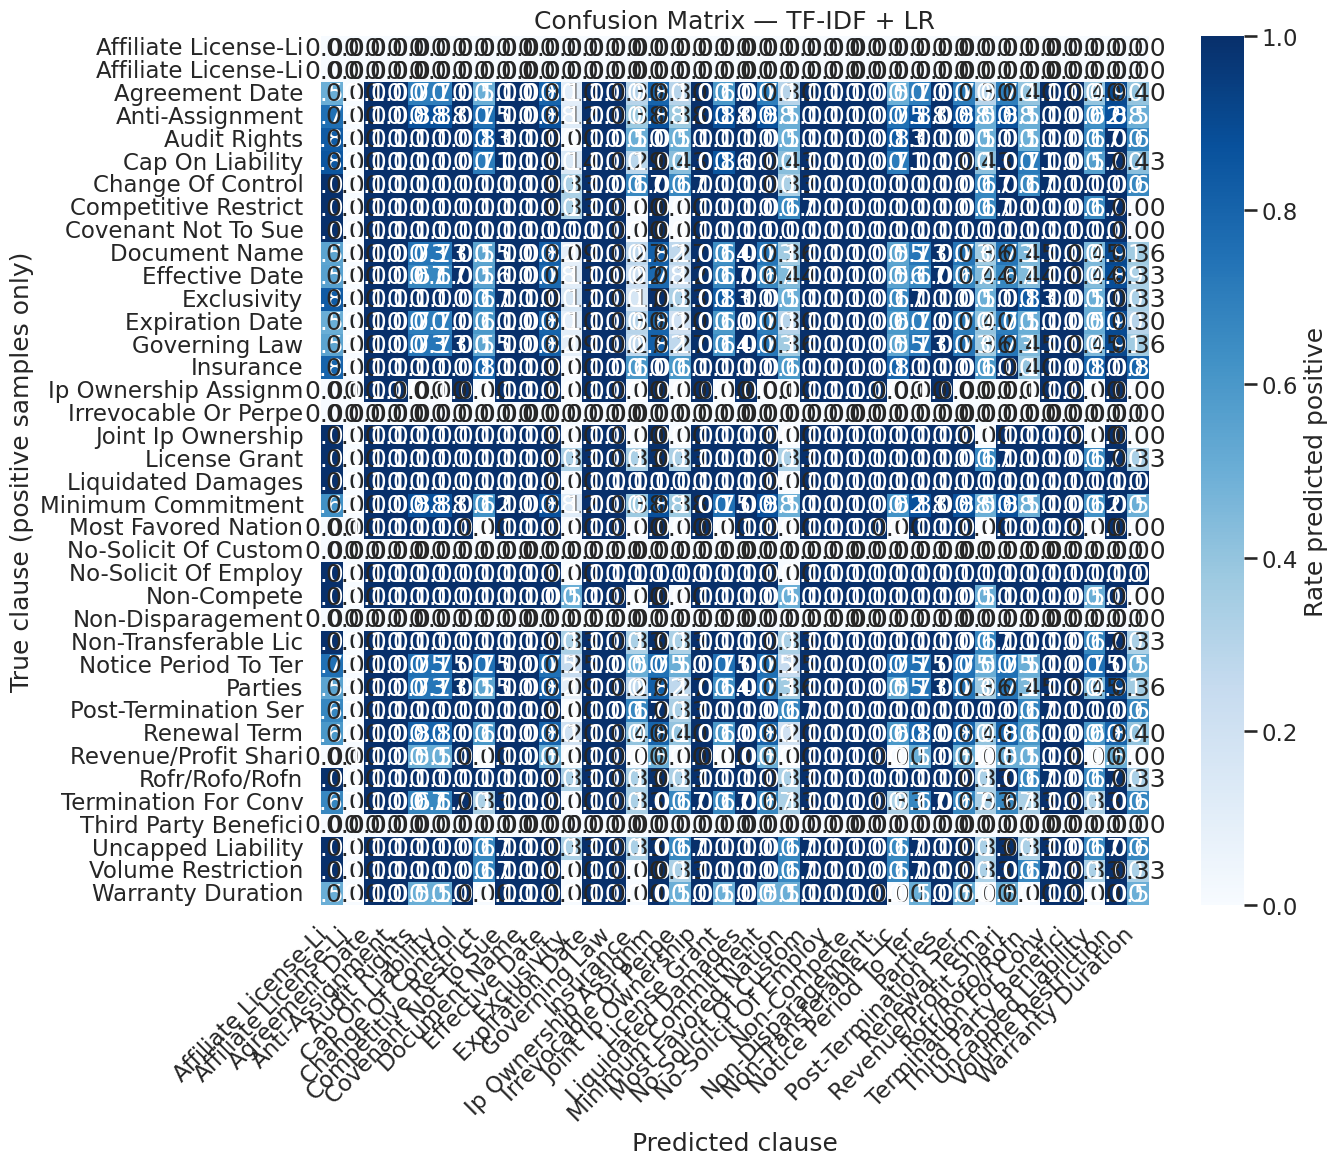

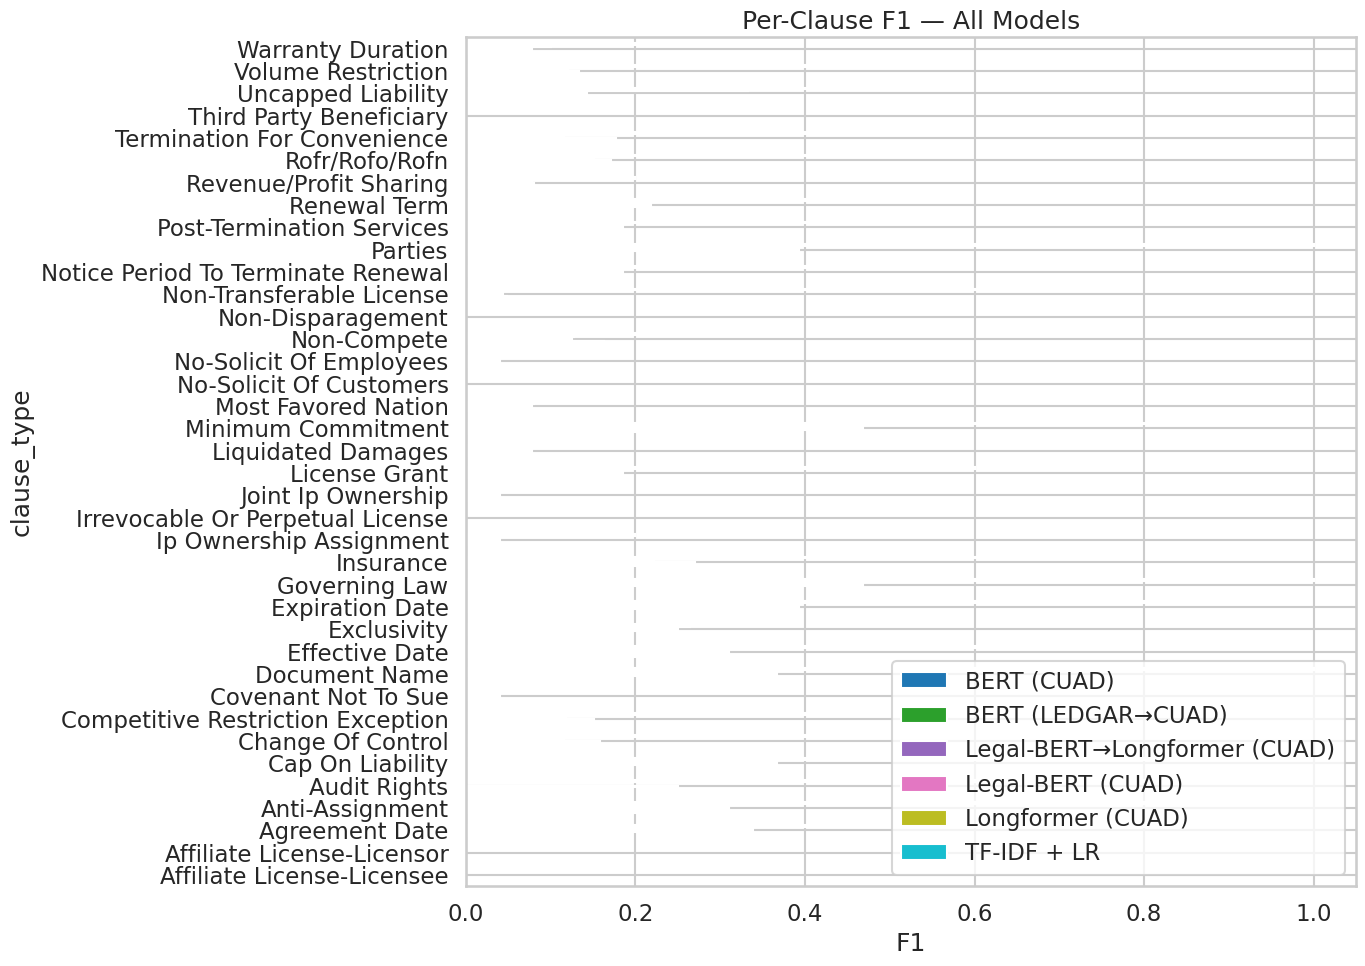

In [25]:
# Section 4 — Evaluate all models
from torch.utils.data import DataLoader as TDL

device = choose_device()
results_per_clause = {}
results_aggregate  = {}

# Cache test logits/labels so we don't re-run inference later
stored_test_logits = {}
stored_test_labels = {}

for art in ALL_ARTIFACTS:
    # Get test logits
    if art.model_name == "TF-IDF + LR":
        test_titles = {r["contract_title"] for r in BERT_SPLITS["test_records"]}
        test_df_sub = filtered_df[filtered_df["contract_title"].isin(test_titles)]
        test_texts  = [grp["contract_text"].iloc[0]
                       for _, grp in test_df_sub.groupby("contract_title")]
        name_to_id  = {v: k for k, v in art.id_to_clause.items()}
        test_label_matrix = np.zeros((len(test_texts), len(art.id_to_clause)))
        for ti, (_, grp) in enumerate(test_df_sub.groupby("contract_title")):
            for _, row in grp.iterrows():
                if row["has_answer"] and row["clause_type"] in name_to_id:
                    test_label_matrix[ti, name_to_id[row["clause_type"]]] = 1.0
        eps = 1e-7
        probs = art.model.predict_proba(test_texts)
        p = np.clip(probs, eps, 1 - eps)
        test_logits = np.log(p / (1 - p))
        test_labels = test_label_matrix
    else:
        splits = LF_SPLITS if "Longformer" in art.model_name else BERT_SPLITS
        test_loader = TDL(splits["test_dataset"], batch_size=8, shuffle=False)
        test_logits, test_labels = collect_logits_and_labels(art.model, test_loader, device)

    # Cache for reuse in confusion matrix and Section 5 — no extra inference pass
    stored_test_logits[art.model_name] = test_logits
    stored_test_labels[art.model_name] = test_labels

    # Tune per-clause thresholds on val logits, apply to test
    per_clause_thresholds = tune_per_clause_thresholds(
        art.val_logits, art.val_labels, art.id_to_clause
    )

    # Per-clause breakdown
    clause_df = compute_per_clause_metrics(
        test_logits, test_labels, per_clause_thresholds,
        art.id_to_clause, n_positive_train,
    )
    results_per_clause[art.model_name] = clause_df

    # Aggregate metrics
    agg = compute_aggregate_metrics(test_logits, test_labels, per_clause_thresholds, art.id_to_clause)
    results_aggregate[art.model_name] = agg
    print(f"{art.model_name:40s}  macro_F1={agg['macro_f1']:.4f}  micro_F1={agg['micro_f1']:.4f}")

# Aggregate comparison table
agg_df = pd.DataFrame(results_aggregate).T.reset_index().rename(columns={"index": "model"})
display(agg_df.sort_values("macro_f1", ascending=False))

# Per-clause breakdown for best model
best_model_name = agg_df.sort_values("macro_f1", ascending=False).iloc[0]["model"]
print(f"\nPer-clause breakdown — {best_model_name}:")
display(results_per_clause[best_model_name])

# Confusion matrix — best model only (uses cached logits, no extra inference)
best_art = next(a for a in ALL_ARTIFACTS if a.model_name == best_model_name)
per_t_best = tune_per_clause_thresholds(best_art.val_logits, best_art.val_labels, best_art.id_to_clause)
safe_name = best_model_name.replace(" ", "_").replace("\u2192", "-")
plot_confusion_matrix(
    stored_test_logits[best_model_name], stored_test_labels[best_model_name],
    per_t_best, best_art.id_to_clause,
    title=f"Confusion Matrix — {best_model_name}",
    save_path=f"figures/confusion_{safe_name}.png",
)

# Model comparison chart
plot_model_comparison(results_per_clause, metric="f1", save_path="figures/model_comparison_f1.png")


In [26]:
# ── Save Section 4 outputs ──────────────────────────────────────────────────
# Run once after Section 4 completes.
# After this runs, right-click s4_outputs.pkl in the VS Code file explorer
# and select Download to save it to your local project folder.
import pickle

best_art_save   = next(a for a in ALL_ARTIFACTS if a.model_name == best_model_name)
splits_for_save = LF_SPLITS if "Longformer" in best_model_name else BERT_SPLITS

s4_data = {
    "best_model_name":  best_model_name,
    "test_logits":      stored_test_logits[best_model_name],
    "per_t_best":       per_t_best,
    "id_to_clause":     best_art_save.id_to_clause,
    "test_examples":    [
        {"contract_title": e["contract_title"],
         "chunk_index":    e["chunk_index"],
         "chunk_text":     e["chunk_text"]}
        for e in splits_for_save["test_examples"]
    ],
}
with open("s4_outputs.pkl", "wb") as f:
    pickle.dump(s4_data, f)
print(f"Saved s4_outputs.pkl  (best model: {best_model_name})")
print("Next: right-click s4_outputs.pkl in VS Code file explorer → Download")


Saved s4_outputs.pkl  (best model: TF-IDF + LR)


## Section 5 — LLM Risk Summaries (Local Ollama)


In [1]:
# Section 5 — LLM Risk Summaries (Local Ollama)
# Run this cell locally in VS Code with a local Python kernel.
# Requires: s4_outputs.pkl in this folder + Ollama running locally.
#
# To start Ollama:  ollama serve
# Models available: ollama list

import pickle, requests, time
import numpy as np
import pandas as pd

# ── Choose your local Ollama model ───────────────────────────────────────────
OLLAMA_MODEL = "llama3.1"   # change to "qwen2.5" or any model from: ollama list
# ─────────────────────────────────────────────────────────────────────────────

OLLAMA_URL = "http://localhost:11434/api/generate"

RISK_PROMPT = """You are a contract risk analyst reviewing a flagged legal clause.

Clause type: {clause_type}
Excerpt: {clause_text}

In plain English, explain:
1. What this clause means and why it matters
2. The severity (Low / Medium / High)
3. One specific thing to watch out for or negotiate"""


def call_ollama(clause_type, clause_text):
    try:
        resp = requests.post(
            OLLAMA_URL,
            json={
                "model":  OLLAMA_MODEL,
                "prompt": RISK_PROMPT.format(
                    clause_type=clause_type,
                    clause_text=clause_text[:800]
                ),
                "stream": False,
            },
            timeout=120,
        )
        resp.raise_for_status()
        return resp.json()["response"]
    except requests.exceptions.ConnectionError:
        return "ERROR: Ollama not running. Start it with: ollama serve"
    except Exception as e:
        return f"ERROR: {e}"


# ── Load Section 4 outputs ────────────────────────────────────────────────────
with open("s4_outputs.pkl", "rb") as f:
    s4 = pickle.load(f)

t_logits      = s4["test_logits"]
per_clause_t  = s4["per_t_best"]
id_to_clause  = s4["id_to_clause"]
test_examples = s4["test_examples"]
print(f"Loaded s4_outputs.pkl")
print(f"Best model from training: {s4['best_model_name']}")
print(f"Test examples: {len(test_examples)}")

# ── Pick top-5 highest-confidence flagged clauses ────────────────────────────
probs = 1 / (1 + np.exp(-t_logits))
rows = []
for chunk_probs, example in zip(probs, test_examples):
    for clause_id, clause_name in id_to_clause.items():
        rows.append({
            "clause_type":    clause_name,
            "score":          float(chunk_probs[clause_id]),
            "chunk_text":     example["chunk_text"],
            "contract_title": example["contract_title"],
        })

top5 = (
    pd.DataFrame(rows)
    .sort_values("score", ascending=False)
    .drop_duplicates(subset=["contract_title", "clause_type"])
    .groupby("clause_type", sort=False).first()
    .reset_index()
    .head(5)
)
print(f"\nSelected clauses: {top5['clause_type'].tolist()}")
print(f"Using model: {OLLAMA_MODEL}\n")

# ── Run LLM on each clause ────────────────────────────────────────────────────
results = []
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"{'='*60}")
    print(f"[{i}/5] {row['clause_type']}")
    print(f"{'='*60}")
    response = call_ollama(row["clause_type"], row["chunk_text"])
    print(response)
    print()
    results.append({
        "clause_type":    row["clause_type"],
        "contract_title": row["contract_title"],
        "score":          round(row["score"], 4),
        "llm_response":   response,
    })

# ── Save results ──────────────────────────────────────────────────────────────
out_df = pd.DataFrame(results)
out_df.to_csv("risk_summary_ratings.csv", index=False)
print("Saved risk_summary_ratings.csv")


FileNotFoundError: [Errno 2] No such file or directory: 's4_outputs.pkl'